# Força de trabalho · absenteísmo, retenção e escala

No caso Vértice, o otimizador de capacidade mostrou que **o gargalo do pico é o recrutamento**. Este notebook desce um nível e responde três perguntas de gestão de pessoas que viram capacidade operacional:

| # | Pergunta | Técnica | KPI |
|---|---|---|---|
| 1 | Quantos vão faltar amanhã? | Regressão com variáveis de calendário + backtest | PE-001 |
| 2 | Quem sai nos primeiros 90 dias, e por quê? | Kaplan-Meier, log-rank, regressão logística | PE-003 |
| 3 | Quantas pessoas escalar, e com quais folgas? | Programação inteira (escala 6x1) | PE-011, PE-012 |

> **Como ler este notebook.** As caixas **🧠 Por dentro do código** explicam a técnica e o Python usado. As caixas **🎯 Leitura executiva** traduzem o resultado em decisão. Dados fictícios, gerados por `kpikit.simulador`.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from kpikit import simulador, pessoas as pe, config as cfg
pd.set_option('display.float_format', '{:,.3f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
d = simulador.carregar()
cd, colab = d['fato_cd'], d['fato_colaboradores']
print(f"{cd.unidade_id.nunique()} CDs · {cd.data.min():%d/%m/%Y}–{cd.data.max():%d/%m/%Y} · {len(colab):,} admissões individuais")

7 CDs · 01/01/2025–30/09/2026 · 7,190 admissões individuais


## 1. Absenteísmo · quantos vão faltar amanhã?

In [2]:
perfil = (cd.dropna(subset=['absenteismo'])
            .assign(dia=lambda x: x.data.dt.dayofweek.map(dict(enumerate(pe.DIAS))))
            .groupby('dia', sort=False).absenteismo.mean().reindex(pe.DIAS))
perfil.to_frame('absenteismo_medio').T

dia,seg,ter,qua,qui,sex,sáb,dom
absenteismo_medio,0.064,0.050,0.049,0.050,0.053,0.049,0.049


🧠 **Por dentro do código · `groupby`.** `groupby('dia').absenteismo.mean()` separa as linhas por dia da semana e tira a média de cada grupo. É o equivalente a uma tabela dinâmica. `.reindex(pe.DIAS)` só coloca os dias na ordem de segunda a domingo.

O perfil mostra um padrão **sistemático**: segunda-feira é pior. Padrão sistemático é previsível. O que sobra depois de explicá-lo é ruído.

In [3]:
prev, m = pe.previsao_absenteismo(d, corte='2026-04-01')
pd.Series(m).to_frame('valor')

,valor
mae_modelo_pp,0.646
mae_ingenuo_pp,0.879
dias_teste,183.000
ganho_vs_ingenuo,0.265
segunda_vs_media_pp,1.390


🧠 **Por dentro do código · o modelo.**
- **Variáveis dummy (one-hot).** O dia da semana é uma categoria, não um número (domingo não é "6 vezes" segunda). `pd.get_dummies` cria uma coluna 0/1 para cada dia, mês e unidade. `drop_first=True` remove uma categoria de cada grupo, que vira a *referência*. Sem isso, as colunas somariam 1 e o modelo não teria solução única (multicolinearidade perfeita).
- **Mínimos quadrados (MQO).** `np.linalg.lstsq` encontra os coeficientes que minimizam a soma dos erros ao quadrado. Cada coeficiente é o efeito daquela condição, em pontos percentuais, com o resto constante.
- **Backtest temporal.** Treinamos até mar/2026 e testamos de abr a set/2026. **Nunca sorteie treino e teste em série temporal**: o modelo "veria o futuro" e o erro pareceria menor do que é.
- **Régua ingênua.** Prever que amanhã será igual ao mesmo dia da semana passada. Um modelo que não bate essa régua não se paga.

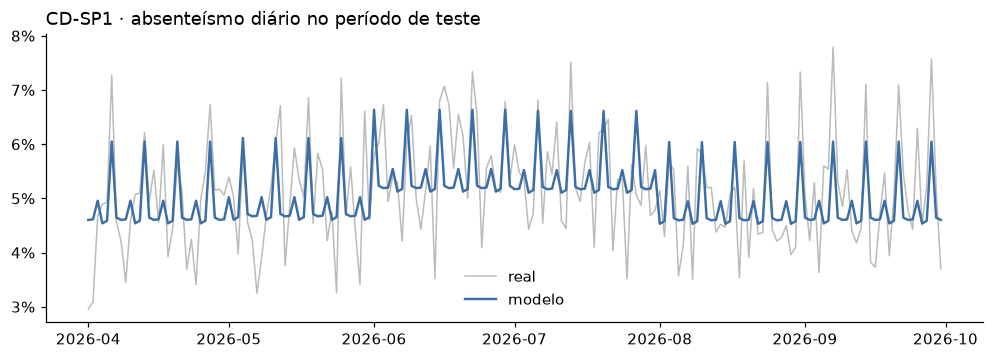

In [4]:
u = prev.query("unidade_id == 'CD-SP1' and amostra == 'teste'").set_index('data')
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(u.index, u.absenteismo, color='#bbb', lw=1, label='real')
ax.plot(u.index, u.previsto, color='#3b6ea5', lw=1.6, label='modelo')
ax.set_title('CD-SP1 · absenteísmo diário no período de teste', loc='left'); ax.legend(frameon=False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

🎯 **Leitura executiva.** O modelo erra em média ~0,65 p.p. por dia, contra ~0,88 p.p. da régua ingênua (**~27% menos erro**). Num CD com 800 operadores, 1 p.p. equivale a 8 pessoas por dia. A diferença entre acertar e errar essa previsão é hora extra de última hora ou pedido fora do cut-off. O modelo **não prevê o ruído** (a gripe de uma pessoa). Ele antecipa o que é **sistemático**: segundas, inverno e a "ressaca" pós-pico. É isso que entra na escala da seção 3.

## 2. Retenção · quem sai nos primeiros 90 dias, e por quê?

🧠 **Por dentro da técnica · censura.** Quem foi admitido em agosto/2026 ainda está no emprego em 30/09/2026, mas **pode sair em outubro**. Se calcularmos "% que saiu em 90 dias" incluindo essas pessoas, o número fica artificialmente baixo. Esse viés se chama **censura à direita**. Há duas formas corretas de lidar com ele:
1. Usar só **coortes maduras** (quem já completou 90 dias). É o que o KPI PE-003 e o KR4.3 fazem.
2. Usar **análise de sobrevivência** (Kaplan-Meier), que aproveita todo mundo e trata quem ainda está ativo como "censurado".

In [5]:
base = pe.base_sobrevivencia(colab, cfg.FIM)
km = pe.kaplan_meier(base.dias, base.evento)
print(f"Retenção em 30 dias: {pe.sobrevivencia_em(km, 30):.1%} · 90 dias: {pe.sobrevivencia_em(km, 90):.1%} · 180 dias: {pe.sobrevivencia_em(km, 180):.1%}")
km.loc[[0, 1, 2, 3]]

Retenção em 30 dias: 79.4% · 90 dias: 68.8% · 180 dias: 62.9%


,saidas,n,em_risco,sobrevivencia,ic_inf,ic_sup
t,,,,,,
0,0,0,7190,1.000,1.000,1.000
1,71,79,7187,0.990,0.988,0.992
2,71,78,7108,0.980,0.977,0.983
3,84,89,7030,0.969,0.964,0.972


🧠 **Por dentro do código · Kaplan-Meier.** Em cada dia *t* em que alguém sai:

$$S(t) = \prod_{t_i \le t}\left(1 - \frac{\text{saídas}_i}{\text{em risco}_i}\right)$$

"Em risco" é quem ainda estava empregado e observado naquele dia. `cumprod()` faz o produtório. O intervalo de confiança usa a fórmula de Greenwood. Em Python, `tabela.n[::-1].cumsum()[::-1]` conta quantos ainda estão em risco em cada dia (soma acumulada de trás para frente).

Log-rank (até 90 dias): χ² = 145.8, p = 1.5e-33


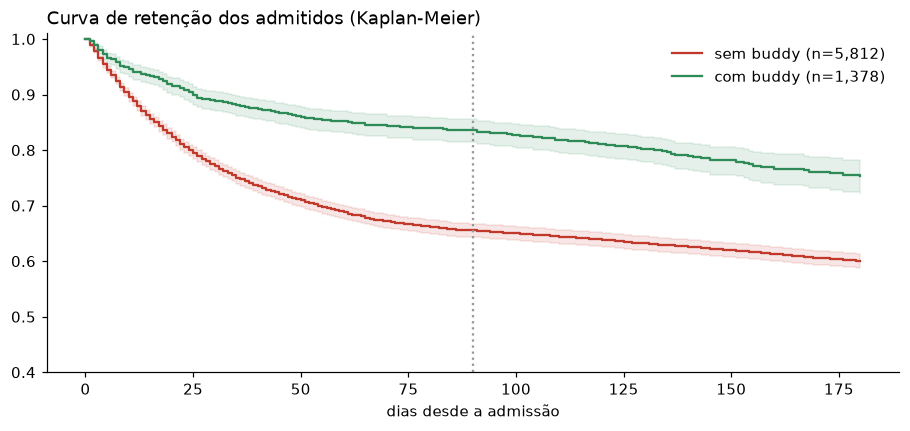

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for valor, cor, rotulo in [(False, '#c0392b', 'sem buddy'), (True, '#2e8b57', 'com buddy')]:
    g = base[base.com_buddy == valor]
    k = pe.kaplan_meier(g.dias, g.evento); k = k[k.index <= 180]
    ax.step(k.index, k.sobrevivencia, where='post', color=cor, label=f'{rotulo} (n={len(g):,})')
    ax.fill_between(k.index, k.ic_inf, k.ic_sup, step='post', color=cor, alpha=0.12)
ax.axvline(90, color='#999', ls=':'); ax.set_ylim(0.4, 1.01)
ax.set_title('Curva de retenção dos admitidos (Kaplan-Meier)', loc='left'); ax.set_xlabel('dias desde a admissão'); ax.legend(frameon=False)
lr = pe.logrank(base.dias.clip(upper=90), base.evento.where(base.dias <= 90, 0), base.com_buddy)
print(f"Log-rank (até 90 dias): χ² = {lr['qui2']:.1f}, p = {lr['p_valor']:.1e}")

🧠 **Por dentro da técnica · log-rank.** Pergunta se as curvas são diferentes além do acaso. Em cada dia com saída, compara quantas saídas *observamos* em cada grupo com quantas *esperaríamos* se o risco fosse igual. Um p-valor minúsculo significa que a diferença não é sorte.

**Cuidado:** o log-rank mostra *que* os grupos diferem, não *por quê*. Quem ganhou buddy pode ter sido admitido numa época diferente, por outro canal etc. Para separar os efeitos, usamos um modelo multivariado.

In [7]:
X, y = pe.matriz_risco_saida(colab, cfg.FIM)
modelo = pe.regressao_logistica(X, y)
modelo[['razao_chances', 'rc_ic_inf', 'rc_ic_sup', 'p_valor']]

,razao_chances,rc_ic_inf,rc_ic_sup,p_valor
intercepto,0.329,0.293,0.369,0.000
turno_noite,1.684,1.500,1.889,0.000
distancia_10km,1.554,1.425,1.694,0.000
canal_agencia,1.576,1.395,1.780,0.000
canal_indicacao,0.676,0.584,0.782,0.000
unidade_3pl,1.315,1.172,1.475,0.000
admitido_em_pico,1.174,1.039,1.327,0.010
com_buddy,0.382,0.315,0.463,0.000


Text(0.0, 1.0, 'Razão de chances de sair em < 90 dias (IC 95%)')

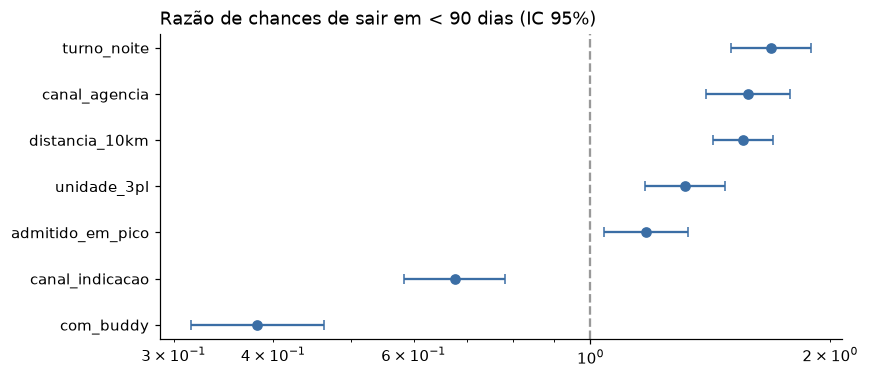

In [8]:
m2 = modelo.drop('intercepto').sort_values('razao_chances')
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.errorbar(m2.razao_chances, range(len(m2)), xerr=[m2.razao_chances - m2.rc_ic_inf, m2.rc_ic_sup - m2.razao_chances],
            fmt='o', color='#3b6ea5', capsize=3)
ax.axvline(1, color='#999', ls='--'); ax.set_yticks(range(len(m2)), m2.index); ax.set_xscale('log')
ax.set_title('Razão de chances de sair em < 90 dias (IC 95%)', loc='left')

🧠 **Por dentro do código · regressão logística.** Modela a *probabilidade* de sair (0 ou 1) com a curva logística. Cada coeficiente é um efeito sobre o log das chances, e **`exp(coef)` é a razão de chances**: 1,7 significa 70% mais chance de sair; 0,4 significa 60% menos. A estimação usa Newton-Raphson: parte de zero e corrige os coeficientes com a curvatura (matriz *H*) até convergir. Os p-valores vêm do erro-padrão, isto é, da raiz da diagonal de *H⁻¹*.

Como os dados são simulados, conhecemos os valores verdadeiros (`simulador.RISCO_SAIDA_90D`). O modelo recupera o sinal e a ordem de grandeza de todos os fatores, com precisão maior nos mais frequentes (buddy, turno, distância). Isso **valida o método** antes de usá-lo em dados reais. Fatores raros ou correlacionados com outros, como a admissão em pico (que coincide com o próprio pico de contratações), são estimados com mais erro. Em dados reais, é aí que mora a cautela.

In [9]:
pd.DataFrame({'verdadeiro (simulação)': pd.Series(simulador.RISCO_SAIDA_90D),
              'estimado': modelo.coef}).round(2)

,verdadeiro (simulação),estimado
intercepto,-1.150,-1.110
turno_noite,0.550,0.520
distancia_10km,0.450,0.440
canal_agencia,0.400,0.450
canal_indicacao,-0.550,-0.390
unidade_3pl,0.350,0.270
admitido_em_pico,0.300,0.160
com_buddy,-0.950,-0.960


In [10]:
custo_saida_precoce = 4_500   # premissa D: recrutamento + integração + produtividade perdida na curva de aprendizagem
maduros = X.assign(saiu=y)
cen = {'hoje': maduros.saiu.mean()}
p = 1 / (1 + np.exp(-(np.column_stack([np.ones(len(X)), X.assign(com_buddy=1)]) @ modelo.coef.to_numpy())))
cen['100% com buddy'] = p.mean()
p = 1 / (1 + np.exp(-(np.column_stack([np.ones(len(X)), X.assign(com_buddy=1, canal_agencia=0)]) @ modelo.coef.to_numpy())))
cen['buddy + sem agência'] = p.mean()
admissoes_ano = 5_000
pd.DataFrame({'taxa_saida_90d': cen}).assign(
    saidas_ano=lambda t: t.taxa_saida_90d * admissoes_ano,
    custo_ano_mi=lambda t: t.saidas_ano * custo_saida_precoce / 1e6)

,taxa_saida_90d,saidas_ano,custo_ano_mi
hoje,0.316,"1,578.304",7.102
100% com buddy,0.170,851.543,3.832
buddy + sem agência,0.147,733.194,3.299


🎯 **Leitura executiva.**
- **Buddy é a alavanca mais forte:** reduz as chances de saída precoce em ~60%, e custa hora de um veterano, não contratação.
- **Canal de recrutamento importa:** indicação retém; agência perde. A política de indicação premiada tem retorno mensurável.
- **Distância e turno noturno** aumentam o risco. Isso vira critério de alocação (quem mora longe não vai para a noite) e de onde abrir o próximo CD.
- Levar o buddy a 100% dos admitidos e reduzir a dependência de agência **evita centenas de saídas por ano**. O valor em reais depende da premissa de custo por saída (R$ 4.500, a validar com Controladoria).
- **Governança:** o KR4.3 é medido na última coorte madura (2T26), nunca no trimestre corrente, por causa da censura.

## 3. Escala · quantas pessoas, e com quais folgas?

In [11]:
nec = pe.necessidade_semanal(d, 'CD-SP1', '2026-04-01', '2026-09-30')
ab = (prev.query("unidade_id == 'CD-SP1' and amostra == 'teste'")
          .assign(dia=lambda x: x.data.dt.dayofweek.map(dict(enumerate(pe.DIAS))))
          .groupby('dia').previsto.mean().reindex(pe.DIAS))
pd.DataFrame({'operadores_presentes_necessarios': nec, 'absenteismo_previsto': ab})

,operadores_presentes_necessarios,absenteismo_previsto
dia,,
seg,820.000,0.063
ter,747.000,0.049
qua,744.000,0.048
qui,713.000,0.048
sex,680.000,0.052
sáb,588.000,0.047
dom,570.000,0.048


🧠 **Por dentro da técnica · o problema da escala 6x1.** Cada operador trabalha 6 dias e folga 1. A decisão é **quantas pessoas folgam em cada dia** (x_seg, …, x_dom), números inteiros. Em cada dia *d*, trabalham todos exceto quem folga em *d*:

$$\Big(\sum_{j \ne d} x_j\Big)\,(1-\text{abs}_d) \ge \text{necessidade}_d \qquad \min \sum_j x_j$$

`scipy.optimize.milp` resolve com *branch and bound*: relaxa a integralidade, resolve o problema contínuo e vai ramificando até achar a melhor solução inteira. A necessidade usa o **percentil 85** da demanda de cada dia, não a média: dimensionar pela média garante falta de gente em metade dos dias.

In [12]:
r = pe.escala_6x1(nec, ab)
print(f"Quadro otimizado: {r.quadro} · quadro plano (pior dia × 7/6): {r.quadro_ingenuo} · "
      f"economia: {r.quadro_ingenuo - r.quadro} pessoas ({1 - r.quadro / r.quadro_ingenuo:.1%}) · ociosidade: {r.horas_ociosas_pct:.1%}")
r.cobertura

Quadro otimizado: 875 · quadro plano (pior dia × 7/6): 1021 · economia: 146 pessoas (14.3%) · ociosidade: 2.4%


,necessidade,escalados,presentes_esperados,folga_no_dia
dia,,,,
seg,820.000,875.000,820.300,0
ter,747.000,786.000,747.900,89
qua,744.000,782.000,744.400,93
qui,713.000,872.000,830.000,3
sex,680.000,718.000,680.900,157
sáb,588.000,618.000,588.800,257
dom,570.000,599.000,570.400,276


In [13]:
custo_mensal_operador = 44 * 38 * 4.33   # 44 h/semana × R$ 38/h (com encargos) × 4,33 semanas
politicas = {f'{f:.0%} do quadro folga no domingo': pe.escala_6x1(nec, ab, folga_domingo_min=f).quadro for f in (0, .20, .33, .50)}
t = pd.Series(politicas, name='quadro').to_frame()
t['custo_adicional_ano_mi'] = (t.quadro - t.quadro.iloc[0]) * custo_mensal_operador * 12 / 1e6
t

,quadro,custo_adicional_ano_mi
0% do quadro folga no domingo,875,0.000
20% do quadro folga no domingo,875,0.000
33% do quadro folga no domingo,895,1.738
50% do quadro folga no domingo,1198,28.061


🎯 **Leitura executiva.**
- **Desenhar as folgas pelo perfil da semana** reduz o quadro em ~14% no CD-SP1 em relação a dimensionar pelo pior dia. É o ganho mais barato de produtividade que existe: não exige capex nem tecnologia.
- **Política de folga no domingo tem preço, e ele não é linear.** Até 20% do quadro folgando no domingo não custa nada (a solução ótima já faz isso). Garantir um terço custa ~20 pessoas (~R$ 1,7 mi/ano). Metade do quadro custa ~320 pessoas (~R$ 28 mi/ano). É uma decisão conjunta de RH e Operações, com o número na mesa, que envolve qualidade de vida, retenção e eventuais exigências de acordo coletivo.
- ⚠️ **Jurídico.** Regras de descanso semanal remunerado, trabalho aos domingos e regimes 6x1 ou 12x36 dependem de CLT, convenção coletiva e atividade. O modelo aceita essas regras como restrições, mas **não substitui a validação jurídica**.
- **Fecha o ciclo:** a previsão de absenteísmo (seção 1) entra direto na escala. Errar 1 p.p. de absenteísmo no domingo = escalar gente a menos exatamente no dia de menor quadro.

---
*KPIs relacionados: PE-001 (absenteísmo), PE-003 (turnover precoce), PE-006 (polivalência), PE-011 (cobertura da escala), PE-012 (ociosidade da escala). Material de portfólio com dados fictícios.*